# GRL Miniproject: Oversmoothing vs. Over-Squashing

**Research Question:** 

Do skip connections and graph rewiring complement each other in addressing oversmoothing and over-squashing , or does fixing the one worsen the other?

**2×2 experiment grid:**

| | Original graph | Rewired graph (SDRF) |
|---|---|-->>-|
| **GCN** | Baseline | Rewiring only |
| **SkipGCN** | Skip only | Skip + Rewiring |

Measured on:
- **Graph A** (oversmoothing): Stochastic Block Model - dense communities, label = community index
- **Graph B** (over-squashing): Barbell graph - two dense clusters joined by a bridge path, label = clique membership

## 0. Setup and main configurations

In [1]:
# Install dependencies
# !pip install -r requirements.txt

In [2]:
import sys
sys.path.insert(0, 'src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

from models import GCN, SkipGCN
from graphs import make_sbm_graph, make_barbell_graph, make_barbell_dataset, split_dataset, train_val_test_split
from rewiring import sdrf_rewire, sdrf_rewire_batch, curvature_stats, compute_ricci_curvature
from metrics import mean_average_distance, dirichlet_energy, sensitivity_vs_distance
from training import train_model, evaluate, train_graph_model, evaluate_graph_model


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED    = 42
# We repeat every accuracy experiment over several seeds and report mean ± std,
# so the results don't rest on one lucky/unlucky run.
# Each seed controls model initialisation AND (for the barbell) data generation.
SEEDS   = [42, 0, 1, 2, 3]
HID_DIM = 64
LAYERS  = [2, 4, 8, 16]
TRAIN_PARAMS = dict(lr=0.01, weight_decay=5e-4, epochs=300, patience=20, device=DEVICE)

COLORS = {
    'GCN': '#4878CF', 'SkipGCN': '#D65F5F',
    'GCN+Rewire': '#6ACC65', 'Skip+Rewire': '#B47CC7',
}
LINESTYLES = {'GCN': '-', 'SkipGCN': '--', 'GCN+Rewire': '-.', 'Skip+Rewire': ':'}


def aggregate(raw: dict):
    """Turn per-seed results into mean/std curves.

    raw[name] is a list (one entry per seed) of equal-length rows. We stack them
    and reduce over the seed axis, giving a mean and std array per condition.
    """
    mean = {n: np.array(v).mean(axis=0) for n, v in raw.items()}
    std  = {n: np.array(v).std(axis=0)  for n, v in raw.items()}
    return mean, std


torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}  |  seeds: {SEEDS}')

Device: cpu  |  seeds: [42, 0, 1, 2, 3]


## 1. Graph Construction

- **SBM**: 4 communities × 50 nodes, high intra-community density -> triggers oversmoothing
- **Barbell**: two cliques (5 nodes each) joined by a bridge path of length 3 -> clear topological bottleneck for over-squashing. This is the *same* topology used throughout Experiments B and C; here we build one representative instance for curvature statistics and visualization.

In [3]:
# Graph A: SBM - for demonstrating oversmoothing
data_sbm = train_val_test_split(
    make_sbm_graph(n_communities=4, nodes_per_community=50,
                   p_intra=0.7, p_inter=0.02, feature_dim=16, seed=SEED),
    seed=SEED)
print('SBM:', data_sbm)

# Graph B: Barbell - for demonstrating over-squashing.
data_barbell = make_barbell_graph(clique_size=5, bridge_length=3, feature_dim=4, seed=SEED)
print('Barbell (clique=5, bridge=3):', data_barbell)

SBM: Data(edge_index=[2, 7536], block=[200], partition=[4], name='stochastic_block_model', num_nodes=200, x=[200, 16], y=[200], num_classes=4, train_mask=[200], val_mask=[200], test_mask=[200])
Barbell (clique=5, bridge=3): Data(edge_index=[2, 46], num_nodes=12, x=[12, 4], y=[12], num_classes=2, clique_size=5, bridge_length=3)


## 2. Graph Rewiring (SDRF)

SDRF iteratively adds edges at the most negatively curved (bottleneck) locations.
We use **α=0** (pure neighbor mass) so that edges with no shared triangle structure get negative curvature - this identifies our topological bottlenecks.

In [4]:
# Curvature stats before rewiring
print('Curvature stats (original graphs):')
for name, g in [('SBM', data_sbm), ('Barbell', data_barbell)]:
    s = curvature_stats(g)
    print(f'  {name:8s}  mean κ={s["mean"]:+.3f}  min κ={s["min"]:+.3f}  '
          f'n_negative={s["n_negative"]}/{s["n_edges"]}')

Curvature stats (original graphs):
  SBM       mean κ=+0.486  min κ=-0.719  n_negative=612/3768
  Barbell   mean κ=+0.548  min κ=-0.600  n_negative=4/23


In [5]:
print('Rewiring SBM...')
data_sbm_rew = sdrf_rewire(data_sbm, n_iterations=30, tau=0.0)
print(f'  SBM edges:     {data_sbm.edge_index.size(1)//2} -> {data_sbm_rew.edge_index.size(1)//2}')

print('Rewiring Barbell...')
data_barbell_rew = sdrf_rewire(data_barbell, n_iterations=20, tau=0.0)
print(f'  Barbell edges: {data_barbell.edge_index.size(1)//2} -> {data_barbell_rew.edge_index.size(1)//2}')

Rewiring SBM...
  SBM edges:     3768 -> 3798
Rewiring Barbell...
  Barbell edges: 23 -> 35


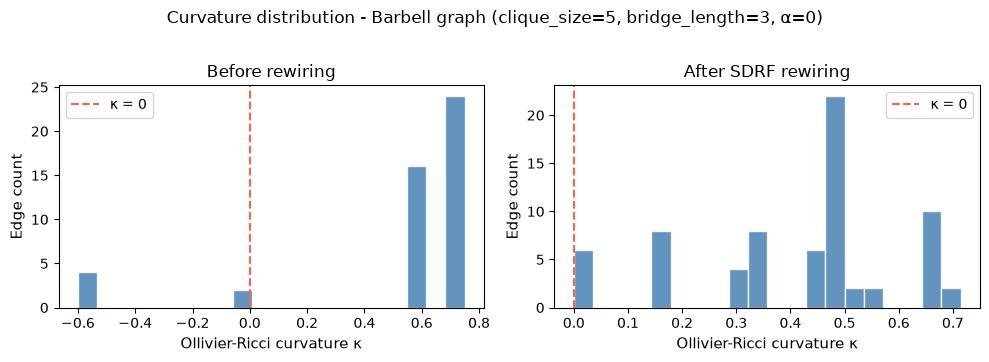

In [6]:
# Curvature distribution of the barbell (clique_size=5, bridge_length=3) before vs after rewiring.
curv_before = list(compute_ricci_curvature(data_barbell).values())
curv_after  = list(compute_ricci_curvature(data_barbell_rew).values())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=False)
for ax, vals, title in zip(axes,
                            [curv_before, curv_after],
                            ["Before rewiring", "After SDRF rewiring"]):
    ax.hist(vals, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="tomato", lw=1.5, linestyle="--", label="κ = 0")
    ax.set_xlabel("Ollivier-Ricci curvature κ", fontsize=11)
    ax.set_ylabel("Edge count", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
plt.suptitle("Curvature distribution - Barbell graph (clique_size=5, bridge_length=3, α=0)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("curvature_distributions.pdf", bbox_inches="tight")
plt.show()

### Barbell topology - before and after rewiring

The signal-propagation task plants a binary signal at the **source** (node 0, left clique) and reads it out only at the **target** (node `clique_size`, right clique). In the original graph these are separated by a long, thin bridge - the over-squashing bottleneck. SDRF adds shortcut edges (green) concentrated at the most negatively curved bridge endpoints, collapsing the bottleneck.

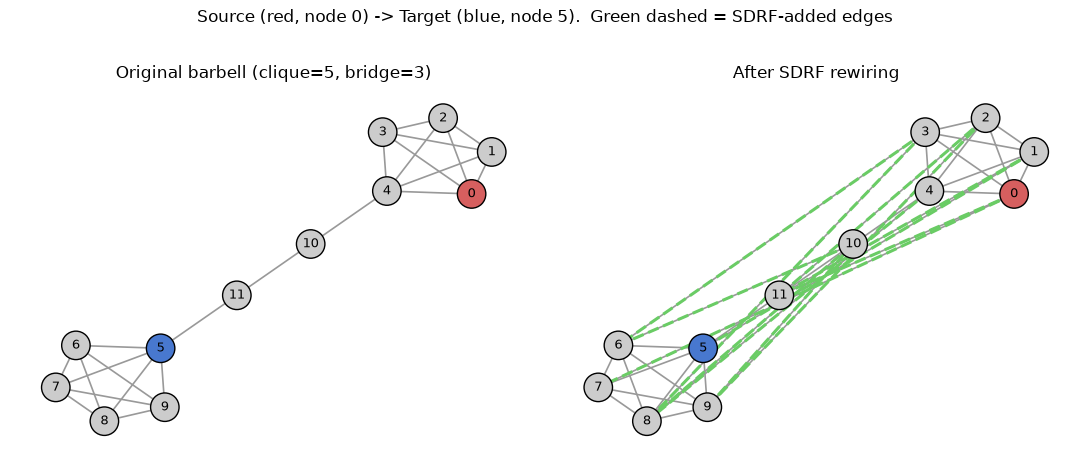

In [7]:
src_node = 0
tgt_node = int(data_barbell.clique_size)   # first node of the right clique

G_orig = to_networkx(data_barbell,     to_undirected=True)
G_rew  = to_networkx(data_barbell_rew, to_undirected=True)
pos    = nx.kamada_kawai_layout(G_orig)

def _node_colors(G):
    out = []
    for n in G.nodes():
        if   n == src_node: out.append('#D65F5F')   # source = red
        elif n == tgt_node: out.append('#4878CF')   # target = blue
        else:               out.append('#cccccc')
    return out

orig_edge_set = set(map(frozenset, G_orig.edges()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, G, title in [(axes[0], G_orig, 'Original barbell (clique=5, bridge=3)'),
                     (axes[1], G_rew,  'After SDRF rewiring')]:
    added = [e for e in G.edges() if frozenset(e) not in orig_edge_set]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#999999', width=1.2)
    if added:
        nx.draw_networkx_edges(G, pos, edgelist=added, ax=ax,
                               edge_color='#6ACC65', width=2.2, style='dashed')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=_node_colors(G),
                           node_size=420, edgecolors='black')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
    ax.set_title(title, fontsize=12); ax.axis('off')

plt.suptitle('Source (red, node 0) -> Target (blue, node 5).  '
             'Green dashed = SDRF-added edges', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('barbell_topology.pdf', bbox_inches='tight')
plt.show()

## 3. Experiment A: Oversmoothing on SBM Graph

Sweep depth K ∈ {2, 4, 8, 16} for all 4 conditions, repeated over several seeds (reported as mean ± std). The SBM graph is held fixed; each seed re-initialises the model, so the error bars show how robust the depth-collapse is to initialisation.

**Metrics:**
- **MAD** (Mean Average Distance): cosine distance between all node embedding pairs. High = distinguishable = not oversmoothed.
- **Dirichlet Energy**: mean squared difference across edges. Collapses to 0 under oversmoothing.
- **Test Accuracy**: downstream classification performance.

In [8]:
conditions_sbm = {
    'GCN':         (GCN,     data_sbm),
    'SkipGCN':     (SkipGCN, data_sbm),
    'GCN+Rewire':  (GCN,     data_sbm_rew),
    'Skip+Rewire': (SkipGCN, data_sbm_rew),
}
in_dim_sbm = data_sbm.x.size(1)
n_cls_sbm  = data_sbm.num_classes

# The SBM graph (and its rewired version) is held fixed across seeds; only the
# model initialisation + training vary. So the error bars here are the 
# answer to "is the depth-collapse robust to initialisation?".
# raw_*[name] = list over seeds, each entry a row over LAYERS.
raw_mad = {n: [] for n in conditions_sbm}
raw_de  = {n: [] for n in conditions_sbm}
raw_acc = {n: [] for n in conditions_sbm}

for seed in SEEDS:
    print(f'seed={seed}')
    for name, (Cls, graph) in conditions_sbm.items():
        mad_row, de_row, acc_row = [], [], []
        for K in LAYERS:
            torch.manual_seed(seed)
            model = Cls(in_dim_sbm, HID_DIM, n_cls_sbm, K)
            model, _, _ = train_model(model, graph, **TRAIN_PARAMS)
            emb = model.embed(graph.x.to(DEVICE), graph.edge_index.to(DEVICE)).cpu()
            mad_row.append(mean_average_distance(emb))
            de_row.append(dirichlet_energy(emb, graph.edge_index))
            acc_row.append(evaluate(model, graph, graph.test_mask, DEVICE))
        raw_mad[name].append(mad_row)
        raw_de[name].append(de_row)
        raw_acc[name].append(acc_row)

# Aggregate to mean/std curves over LAYERS
results_mad,     results_mad_std     = aggregate(raw_mad)
results_de,      results_de_std      = aggregate(raw_de)
results_acc_sbm, results_acc_sbm_std = aggregate(raw_acc)

print(f'\nMean over {len(SEEDS)} seeds (± std):')
for K_i, K in enumerate(LAYERS):
    print(f'\nK={K}')
    for name in conditions_sbm:
        print(f'  {name:15s}  MAD={results_mad[name][K_i]:.3f}±{results_mad_std[name][K_i]:.3f}'
              f'  Acc={results_acc_sbm[name][K_i]:.3f}±{results_acc_sbm_std[name][K_i]:.3f}')

seed=42
seed=0
seed=1
seed=2
seed=3

Mean over 5 seeds (± std):

K=2
  GCN              MAD=0.343±0.037  Acc=1.000±0.000
  SkipGCN          MAD=0.732±0.024  Acc=0.885±0.054
  GCN+Rewire       MAD=0.339±0.037  Acc=1.000±0.000
  Skip+Rewire      MAD=0.737±0.024  Acc=0.885±0.058

K=4
  GCN              MAD=0.334±0.091  Acc=0.995±0.010
  SkipGCN          MAD=0.555±0.041  Acc=0.925±0.063
  GCN+Rewire       MAD=0.325±0.092  Acc=1.000±0.000
  Skip+Rewire      MAD=0.556±0.042  Acc=0.925±0.063

K=8
  GCN              MAD=0.329±0.047  Acc=0.640±0.227
  SkipGCN          MAD=0.381±0.040  Acc=0.965±0.034
  GCN+Rewire       MAD=0.290±0.056  Acc=0.440±0.147
  Skip+Rewire      MAD=0.379±0.028  Acc=0.970±0.037

K=16
  GCN              MAD=0.000±0.000  Acc=0.185±0.034
  SkipGCN          MAD=0.468±0.042  Acc=0.860±0.256
  GCN+Rewire       MAD=0.000±0.000  Acc=0.210±0.030
  Skip+Rewire      MAD=0.417±0.107  Acc=0.700±0.322


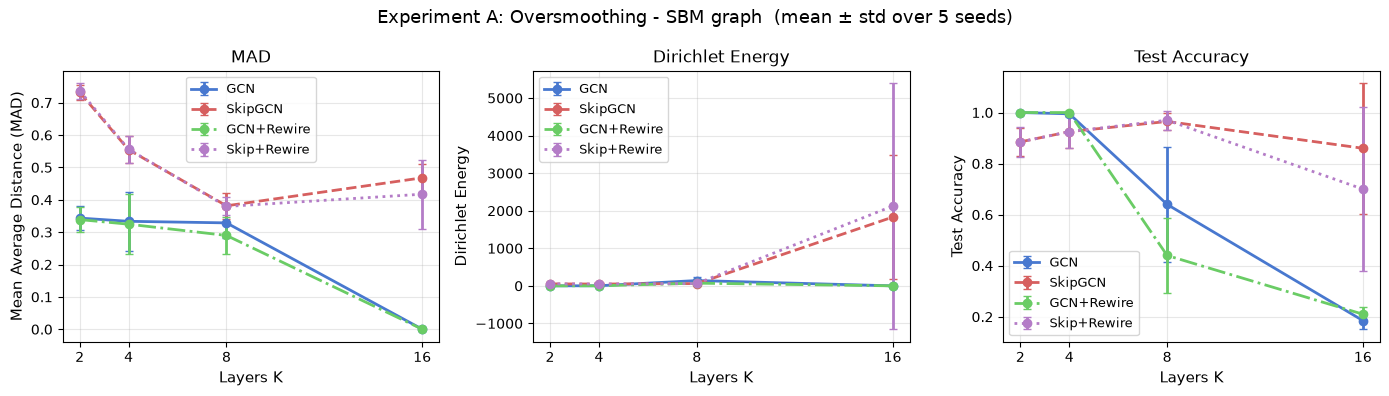

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (mean_d, std_d, ylabel, title) in zip(axes, [
    (results_mad,     results_mad_std,     'Mean Average Distance (MAD)', 'MAD'),
    (results_de,      results_de_std,      'Dirichlet Energy',            'Dirichlet Energy'),
    (results_acc_sbm, results_acc_sbm_std, 'Test Accuracy',               'Test Accuracy'),
]):
    for name in mean_d:
        ax.errorbar(LAYERS, mean_d[name], yerr=std_d[name], marker='o', label=name,
                    color=COLORS[name], linestyle=LINESTYLES[name], lw=2, capsize=3)
    ax.set_xlabel('Layers K', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(LAYERS)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Experiment A: Oversmoothing - SBM graph  (mean ± std over {len(SEEDS)} seeds)', fontsize=13)
plt.tight_layout()
plt.savefig('exp_a_oversmoothing.pdf', bbox_inches='tight')
plt.show()

## 4. Experiment B: Over-Squashing - Source-to-Target Signal Propagation

We generate a dataset of **barbell graphs** (two cliques connected by a bridge path).
Each graph has a binary signal planted at **source node 0** (left clique).
The model must predict this signal using ONLY the **target node** (first node of right clique).

Distance source > target =  hops (node 0 is 1 hop from the bridgeentry within the dense left clique, then  more hops across the bridge).

### B.1 - Vary depth K (fixed bridge_length=3, distance=4 hops)

In [ ]:
BRIDGE_FIXED = 3   # source-to-target distance = 1 + 3 = 4 hops
CLIQUE_SIZE  = 5
FEAT_DIM_BB  = 4
N_GRAPHS     = 400
TRAIN_PARAMS_BB = dict(lr=0.005, weight_decay=1e-4, epochs=300, patience=30, batch_size=32, device=DEVICE)

# Fixed dataset (seed=SEED) - kept around for the Jacobian analysis (Exp C).
graphs_fixed = make_barbell_dataset(N_GRAPHS, CLIQUE_SIZE, BRIDGE_FIXED, FEAT_DIM_BB, SEED)
print(f"{N_GRAPHS} graphs, source-to-target distance: 1 + {BRIDGE_FIXED} = {1+BRIDGE_FIXED} hops")

# Multi-seed: each seed re-draws the dataset AND re-initialises the model.
# raw_acc_bb[name] = list over seeds, each a row over LAYERS.
raw_acc_bb = {n: [] for n in ["GCN", "SkipGCN"]}

for seed in SEEDS:
    print(f"seed={seed}")
    graphs_s = make_barbell_dataset(N_GRAPHS, CLIQUE_SIZE, BRIDGE_FIXED, FEAT_DIM_BB, seed)
    train_g, val_g, test_g = split_dataset(graphs_s, seed=seed)
    for name, Cls in [("GCN", GCN), ("SkipGCN", SkipGCN)]:
        acc_row = []
        for K in LAYERS:
            torch.manual_seed(seed)
            model = Cls(FEAT_DIM_BB, HID_DIM, 2, K)
            model, _, _ = train_graph_model(model, train_g, val_g, **TRAIN_PARAMS_BB)
            acc_row.append(evaluate_graph_model(model, test_g, device=DEVICE))
        raw_acc_bb[name].append(acc_row)

results_acc_bb, results_acc_bb_std = aggregate(raw_acc_bb)

print(f'\nMean over {len(SEEDS)} seeds (± std):')
for K_i, K in enumerate(LAYERS):
    print(f'  K={K:2d}  ' + '  '.join(
        f'{name}={results_acc_bb[name][K_i]:.3f}±{results_acc_bb_std[name][K_i]:.3f}'
        for name in raw_acc_bb))

400 graphs, source-to-target distance: 1 + 3 = 4 hops
seed=42
seed=0
seed=1
seed=2
seed=3

Mean over 5 seeds (± std):
  K= 2  GCN=0.460±0.018  SkipGCN=0.478±0.056
  K= 4  GCN=0.787±0.260  SkipGCN=0.797±0.252
  K= 8  GCN=0.565±0.218  SkipGCN=1.000±0.000
  K=16  GCN=0.475±0.036  SkipGCN=0.997±0.005


### B.2 - Vary bridge length (fixed K=8)

Longer bridge = longer required range AND stronger bottleneck.
We also apply SDRF rewiring per bridge length and compare all four conditions, averaged over several seeds (each seed re-draws the 400-graph dataset and re-initialises the model). The rewired topology is identical across seeds, so it is computed once and reused — only the planted signal/noise differs per seed. Otherwise it would take much much longer to run the experiment, and the rewiring is deterministic anyway.

In [11]:
BRIDGE_LENGTHS = [1, 2, 3, 4, 5, 7]
FIXED_K = 8
COND_NAMES = ["GCN", "SkipGCN", "GCN+Rewire", "Skip+Rewire"]

# --- Rewire once (topology is seed-independent) ---
# A barbell's wiring only depends on clique_size/bridge_length, not on the seed,
# so the rewired topology is identical for every seed. We compute it a single
# time here and reuse the edge_index across all seeds and all 400 instances.
print("Rewiring all bridge lengths in one subprocess call...")
templates = [make_barbell_dataset(1, CLIQUE_SIZE, bl, FEAT_DIM_BB, SEED)[0]
             for bl in BRIDGE_LENGTHS]
rewired_templates = sdrf_rewire_batch(templates, n_iterations=20, tau=0.0)
rewired_edge_indexes = [rt.edge_index for rt in rewired_templates]
for bl, tmpl, rt in zip(BRIDGE_LENGTHS, templates, rewired_templates):
    print(f"  bridge_length={bl}: {tmpl.edge_index.size(1)//2} -> {rt.edge_index.size(1)//2} edges")

# --- Multi-seed sweep ---
# raw_bridge[name] = list over seeds, each a row over BRIDGE_LENGTHS.
raw_bridge = {n: [] for n in COND_NAMES}

for seed in SEEDS:
    print(f"\nseed={seed}")
    rows = {n: [] for n in COND_NAMES}
    for bl, rew_ei in zip(BRIDGE_LENGTHS, rewired_edge_indexes):
        graphs_bl = make_barbell_dataset(N_GRAPHS, CLIQUE_SIZE, bl, FEAT_DIM_BB, seed)
        # Reuse rewired topology — only the features/labels differ per instance.
        graphs_bl_rew = [
            Data(x=g.x, edge_index=rew_ei, y=g.y,
                 num_nodes=g.num_nodes, target_node=g.target_node)
            for g in graphs_bl
        ]
        train_bl,  val_bl,  test_bl  = split_dataset(graphs_bl,     seed=seed)
        train_blr, val_blr, test_blr = split_dataset(graphs_bl_rew, seed=seed)
        splits = {
            "GCN":         (train_bl,  val_bl,  test_bl),
            "SkipGCN":     (train_bl,  val_bl,  test_bl),
            "GCN+Rewire":  (train_blr, val_blr, test_blr),
            "Skip+Rewire": (train_blr, val_blr, test_blr),
        }
        for name in COND_NAMES:
            tr, vl, te = splits[name]
            Cls = SkipGCN if "Skip" in name else GCN
            torch.manual_seed(seed)
            model = Cls(FEAT_DIM_BB, HID_DIM, 2, FIXED_K)
            model, _, _ = train_graph_model(model, tr, vl, **TRAIN_PARAMS_BB)
            rows[name].append(evaluate_graph_model(model, te, device=DEVICE))
        print(f"  bl={bl}: " + "  ".join(f"{n}={rows[n][-1]:.2f}" for n in COND_NAMES))
    for n in COND_NAMES:
        raw_bridge[n].append(rows[n])

results_acc_bridge, results_acc_bridge_std = aggregate(raw_bridge)

print(f'\nMean over {len(SEEDS)} seeds (± std):')
for bl_i, bl in enumerate(BRIDGE_LENGTHS):
    print(f'  bl={bl}  ' + '  '.join(
        f'{n}={results_acc_bridge[n][bl_i]:.3f}±{results_acc_bridge_std[n][bl_i]:.3f}'
        for n in COND_NAMES))

Rewiring all bridge lengths in one subprocess call...
  bridge_length=1: 21 -> 24 edges
  bridge_length=2: 22 -> 30 edges
  bridge_length=3: 23 -> 35 edges
  bridge_length=4: 24 -> 36 edges
  bridge_length=5: 25 -> 40 edges
  bridge_length=7: 27 -> 47 edges

seed=42
  bl=1: GCN=1.00  SkipGCN=1.00  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=2: GCN=1.00  SkipGCN=1.00  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=3: GCN=0.46  SkipGCN=1.00  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=4: GCN=0.54  SkipGCN=1.00  GCN+Rewire=0.99  Skip+Rewire=1.00
  bl=5: GCN=0.50  SkipGCN=0.50  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=7: GCN=0.46  SkipGCN=0.54  GCN+Rewire=1.00  Skip+Rewire=1.00

seed=0
  bl=1: GCN=1.00  SkipGCN=1.00  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=2: GCN=1.00  SkipGCN=1.00  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=3: GCN=0.46  SkipGCN=1.00  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=4: GCN=0.45  SkipGCN=0.54  GCN+Rewire=1.00  Skip+Rewire=1.00
  bl=5: GCN=0.53  SkipGCN=0.38  GCN+Rewire=1.00  Skip+Rewire=1.00

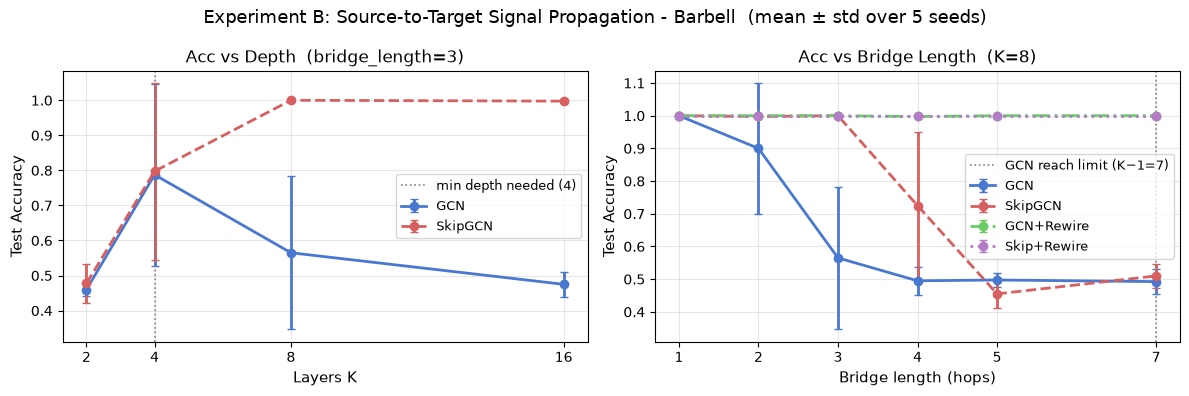

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for name in results_acc_bb:
    ax.errorbar(LAYERS, results_acc_bb[name], yerr=results_acc_bb_std[name],
                marker="o", label=name, color=COLORS[name],
                linestyle=LINESTYLES[name], lw=2, capsize=3)
ax.axvline(1 + BRIDGE_FIXED, color="gray", lw=1.2, linestyle=":",
           label=f"min depth needed ({1+BRIDGE_FIXED})")
ax.set_xlabel("Layers K", fontsize=11)
ax.set_ylabel("Test Accuracy", fontsize=11)
ax.set_title(f"Acc vs Depth  (bridge_length={BRIDGE_FIXED})", fontsize=12)
ax.set_xticks(LAYERS); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
for name in results_acc_bridge:
    ax.errorbar(BRIDGE_LENGTHS, results_acc_bridge[name], yerr=results_acc_bridge_std[name],
                marker="o", label=name, color=COLORS[name],
                linestyle=LINESTYLES[name], lw=2, capsize=3)
# Plain GCN can only reach ~K-1 hops; rewiring breaks this depth=reach assumption
# by shortening the effective bridge, so the rewired conditions succeed past it.
ax.axvline(FIXED_K - 1, color="gray", lw=1.2, linestyle=":",
           label=f"GCN reach limit (K−1={FIXED_K-1})")
ax.set_xlabel("Bridge length (hops)", fontsize=11)
ax.set_ylabel("Test Accuracy", fontsize=11)
ax.set_title(f"Acc vs Bridge Length  (K={FIXED_K})", fontsize=12)
ax.set_xticks(BRIDGE_LENGTHS); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f"Experiment B: Source-to-Target Signal Propagation - Barbell  (mean ± std over {len(SEEDS)} seeds)", fontsize=13)
plt.tight_layout()
plt.savefig("exp_b_oversquashing.pdf", bbox_inches="tight")
plt.show()

## 5. Experiment C: Jacobian Sensitivity vs Distance

We compute the Jacobian norm ||∂h_v^(K) / ∂x_u|| for pairs (u, v) at varying graph distances. This measures how much influence node u's initial features have on node v's final representation - a measure of over-squashing. Exponential decay = strong over-squashing. Curves are averaged over the same seeds as the accuracy experiments (mean ± std); the barbell topology is fixed, so only the trained model varies between seeds.

**Remark on the plot!:** the two rewired conditions (`GCN+Rewire`, `Skip+Rewire`) only have points at distances 1–2. This is not missing data - SDRF adds shortcut edges that collapse the graph diameter, so after rewiring no node pairs remain at distance ≥ 3. The truncated curves are themselves direct evidence that rewiring reduces over-squashing by shortening the longest paths the signal must travel.

In [13]:
JACOBIAN_K = 8
N_PAIRS    = 30
MAX_DIST   = 10

# The barbell topology (original and rewired) is seed-independent, so the set of
# distance buckets is identical across seeds — only the trained model varies.
# That means we can average the sensitivity curves over seeds the same way as the
# accuracy experiments. Rewire the shared topology once and reuse it.
rew_ei_jac = sdrf_rewire(graphs_fixed[0], n_iterations=20, tau=0.0).edge_index

# raw_sens[name] = list over seeds, each a dict {distance: mean Jacobian norm}.
raw_sens = {n: [] for n in COND_NAMES}

for seed in SEEDS:
    graphs_s   = make_barbell_dataset(N_GRAPHS, CLIQUE_SIZE, BRIDGE_FIXED, FEAT_DIM_BB, seed)
    graphs_rew = [
        Data(x=g.x, edge_index=rew_ei_jac, y=g.y,
             num_nodes=g.num_nodes, target_node=g.target_node)
        for g in graphs_s
    ]
    graphs_for = {
        "GCN":         graphs_s,   "SkipGCN":     graphs_s,
        "GCN+Rewire":  graphs_rew, "Skip+Rewire": graphs_rew,
    }
    for name in COND_NAMES:
        gl  = graphs_for[name]
        Cls = SkipGCN if "Skip" in name else GCN
        torch.manual_seed(seed)
        model = Cls(FEAT_DIM_BB, HID_DIM, 2, JACOBIAN_K)
        model, _, _ = train_graph_model(model, *split_dataset(gl, seed=seed)[:2],
                                        **TRAIN_PARAMS_BB)
        # one representative graph per condition (all share the same topology)
        sens = sensitivity_vs_distance(model, gl[0], n_pairs=N_PAIRS,
                                       max_distance=MAX_DIST, device=DEVICE)
        raw_sens[name].append(sens)
    print(f"seed={seed} done")


def aggregate_sens(list_of_dicts):
    """Mean/std per distance across seeds (distances may differ between seeds)."""
    dists = sorted({d for dd in list_of_dicts for d in dd})
    mean, std = {}, {}
    for d in dists:
        vals = [dd[d] for dd in list_of_dicts if d in dd]
        mean[d] = float(np.mean(vals))
        std[d]  = float(np.std(vals))
    return mean, std

jacobian_mean, jacobian_std = {}, {}
for name in COND_NAMES:
    jacobian_mean[name], jacobian_std[name] = aggregate_sens(raw_sens[name])

print(f"\nMean over {len(SEEDS)} seeds:")
for name in COND_NAMES:
    print(f"  {name:12s} " +
          "  ".join(f"d{d}={jacobian_mean[name][d]:.2e}±{jacobian_std[name][d]:.1e}"
                    for d in jacobian_mean[name]))

seed=42 done
seed=0 done
seed=1 done
seed=2 done
seed=3 done

Mean over 5 seeds:
  GCN          d1=4.43e-04±3.1e-04  d2=2.71e-04±2.2e-04  d3=9.61e-05±5.8e-05  d4=7.12e-05±6.3e-05  d5=1.68e-05±1.2e-05
  SkipGCN      d1=5.18e+00±5.2e+00  d2=1.08e+00±8.4e-01  d3=2.03e-01±2.4e-01  d4=7.41e-02±8.9e-02  d5=9.64e-03±1.4e-02
  GCN+Rewire   d1=2.52e-01±4.4e-01  d2=1.86e-01±3.0e-01
  Skip+Rewire  d1=1.60e+00±6.2e-01  d2=1.09e+00±9.6e-01


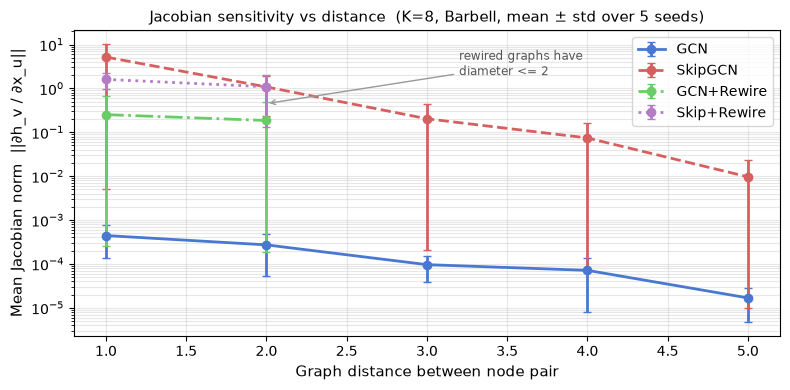

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in COND_NAMES:
    dists = sorted(jacobian_mean[name].keys())
    mean  = np.array([jacobian_mean[name][d] for d in dists])
    std   = np.array([jacobian_std[name][d]  for d in dists])
    # On a log axis the lower error bar must stay positive; clip it just below the mean.
    lower = np.minimum(std, mean * 0.999)
    ax.errorbar(dists, mean, yerr=[lower, std], marker='o', label=name,
                color=COLORS[name], linestyle=LINESTYLES[name], lw=2, capsize=3)

ax.set_xlabel('Graph distance between node pair', fontsize=11)
ax.set_ylabel('Mean Jacobian norm  ||∂h_v / ∂x_u||', fontsize=11)
ax.set_title(f'Jacobian sensitivity vs distance  (K={JACOBIAN_K}, Barbell, mean ± std over {len(SEEDS)} seeds)', fontsize=11)
ax.set_yscale('log')

# Note: rewired curves stop at distance 2 because SDRF shrinks the graph diameter
# (no node pairs remain at distance >= 3) - itself evidence of reduced over-squashing.
ax.annotate('rewired graphs have\ndiameter <= 2', xy=(2, 0.45),
            xytext=(3.2, 2.0), fontsize=8.5, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1))

ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('exp_c_jacobian.pdf', bbox_inches='tight')
plt.show()

## 6. Summary Table

In [15]:
K_IDX  = LAYERS.index(8)
BL_IDX = BRIDGE_LENGTHS.index(3)

def ms(mean_d, std_d, name, idx, dec=3):
    return f"{mean_d[name][idx]:.{dec}f} ± {std_d[name][idx]:.{dec}f}"

rows = []
for name in ["GCN", "SkipGCN", "GCN+Rewire", "Skip+Rewire"]:
    rows.append({
        "Model":                     name,
        "MAD (SBM, K=8)":            ms(results_mad, results_mad_std, name, K_IDX),
        "Acc (SBM, K=8)":            ms(results_acc_sbm, results_acc_sbm_std, name, K_IDX),
        "Acc (Barbell bl=3, K=8)":   ms(results_acc_bridge, results_acc_bridge_std, name, BL_IDX),
    })

df = pd.DataFrame(rows).set_index("Model")
print(f"Mean ± std over {len(SEEDS)} seeds:\n")
print(df.to_string())
df

Mean ± std over 5 seeds:

            MAD (SBM, K=8) Acc (SBM, K=8) Acc (Barbell bl=3, K=8)
Model                                                            
GCN          0.329 ± 0.047  0.640 ± 0.227           0.565 ± 0.218
SkipGCN      0.381 ± 0.040  0.965 ± 0.034           1.000 ± 0.000
GCN+Rewire   0.290 ± 0.056  0.440 ± 0.147           1.000 ± 0.000
Skip+Rewire  0.379 ± 0.028  0.970 ± 0.037           1.000 ± 0.000


,"MAD (SBM, K=8)","Acc (SBM, K=8)","Acc (Barbell bl=3, K=8)"
Model,,,
GCN,0.329 ± 0.047,0.640 ± 0.227,0.565 ± 0.218
SkipGCN,0.381 ± 0.040,0.965 ± 0.034,1.000 ± 0.000
GCN+Rewire,0.290 ± 0.056,0.440 ± 0.147,1.000 ± 0.000
Skip+Rewire,0.379 ± 0.028,0.970 ± 0.037,1.000 ± 0.000
